In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import statsmodels.stats.proportion as sp
import warnings
warnings.filterwarnings("ignore")

In [2]:
df= pd.read_csv('/content/Travel.csv')

In [3]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [4]:
df.shape

(4888, 20)

In [5]:
df.describe()

,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4888.000000,4888.000000,4662.000000,4888.000000,4637.000000,4888.000000,4843.000000,4862.000000,4748.000000,4888.000000,4888.000000,4888.000000,4822.000000,4655.000000
mean,202443.500000,0.188216,37.622265,1.654255,15.490835,2.905074,3.708445,3.581037,3.236521,0.290917,3.078151,0.620295,1.187267,23619.853491
std,1411.188388,0.390925,9.316387,0.916583,8.519643,0.724891,1.002509,0.798009,1.849019,0.454232,1.365792,0.485363,0.857861,5380.698361
min,200000.000000,0.000000,18.000000,1.000000,5.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1000.000000
25%,201221.750000,0.000000,31.000000,1.000000,9.000000,2.000000,3.000000,3.000000,2.000000,0.000000,2.000000,0.000000,1.000000,20346.000000
50%,202443.500000,0.000000,36.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,3.000000,1.000000,1.000000,22347.000000
75%,203665.250000,0.000000,44.000000,3.000000,20.000000,3.000000,4.000000,4.000000,4.000000,1.000000,4.000000,1.000000,2.000000,25571.000000
max,204887.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,5.000000,1.000000,3.000000,98678.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [7]:
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,226
TypeofContact,25
CityTier,0
DurationOfPitch,251
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,45


In [8]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [9]:
df.Gender.unique()

array(['Female', 'Male', 'Fe Male'], dtype=object)

In [10]:
df.replace('Fe Male', 'Female', inplace = True)

In [11]:
df.Gender.value_counts()

,count
Gender,
Male,2916
Female,1972


In [12]:
df.isnull().sum().sort_values(ascending = False)

,0
DurationOfPitch,251
MonthlyIncome,233
Age,226
NumberOfTrips,140
NumberOfChildrenVisiting,66
NumberOfFollowups,45
PreferredPropertyStar,26
TypeofContact,25
CustomerID,0
ProdTaken,0


In [13]:
round(100*(df.isnull().sum()/len(df.index)),2).sort_values(ascending = False)

,0
DurationOfPitch,5.14
MonthlyIncome,4.77
Age,4.62
NumberOfTrips,2.86
NumberOfChildrenVisiting,1.35
NumberOfFollowups,0.92
PreferredPropertyStar,0.53
TypeofContact,0.51
CustomerID,0.00
ProdTaken,0.00


In [14]:
df.isnull().mean()

,0
CustomerID,0.000000
ProdTaken,0.000000
Age,0.046236
TypeofContact,0.005115
CityTier,0.000000
DurationOfPitch,0.051350
Occupation,0.000000
Gender,0.000000
NumberOfPersonVisiting,0.000000
NumberOfFollowups,0.009206


In [15]:
df.dtypes

,0
CustomerID,int64
ProdTaken,int64
Age,float64
TypeofContact,object
CityTier,int64
DurationOfPitch,float64
Occupation,object
Gender,object
NumberOfPersonVisiting,int64
NumberOfFollowups,float64


In [16]:
cat_col = [col for col in df.columns if df[col].dtypes == 'object']
cat_col

['TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [17]:
num_col = [col for col in df.columns if df[col].dtypes != 'object']
num_col

['CustomerID',
 'ProdTaken',
 'Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

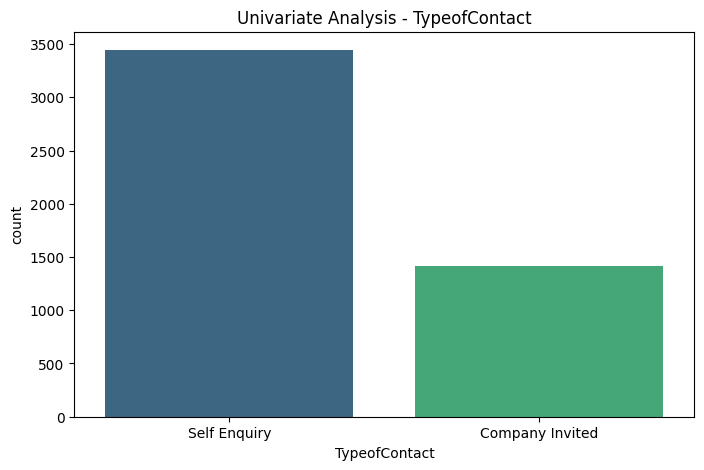

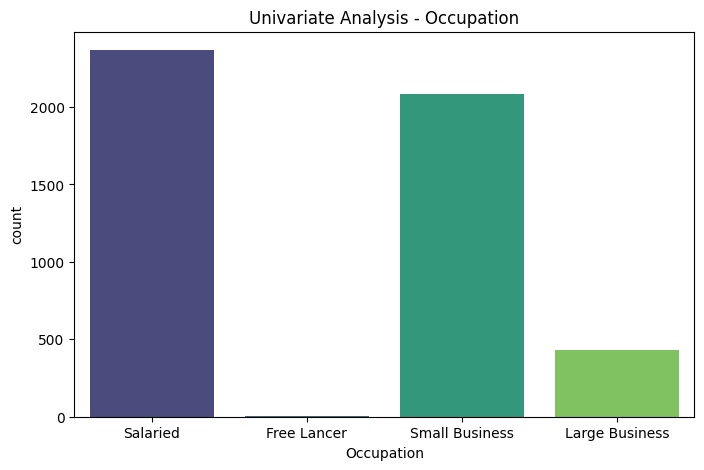

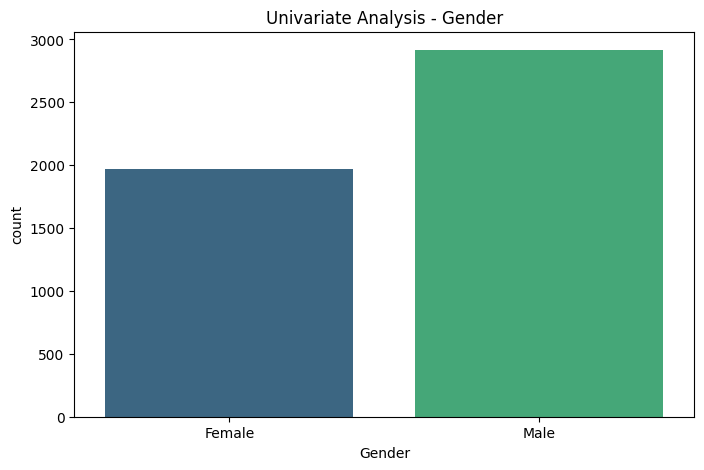

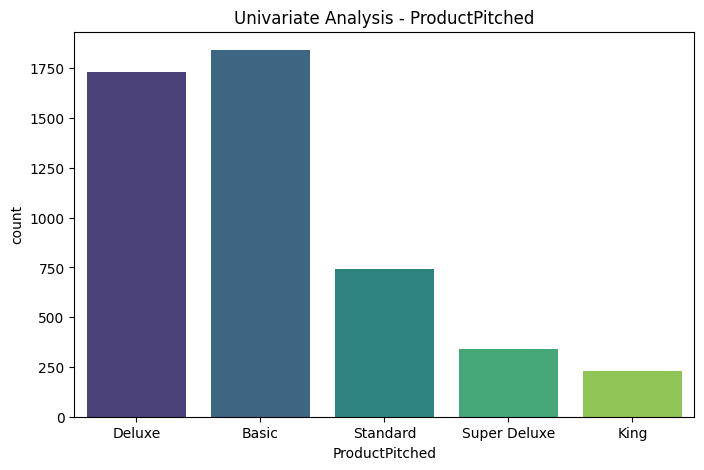

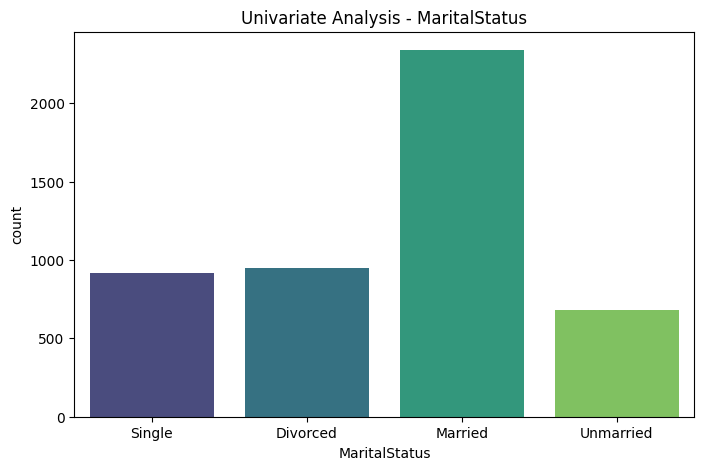

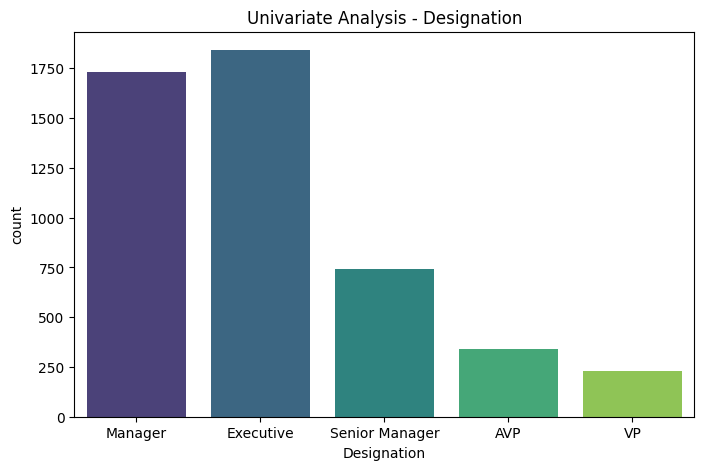

In [18]:
for column in cat_col:
  plt.figure(figsize = (8,5))
  sns.countplot(x = column, data = df, palette = 'viridis')
  plt.title(f"Univariate Analysis - {column}")
  plt.show()

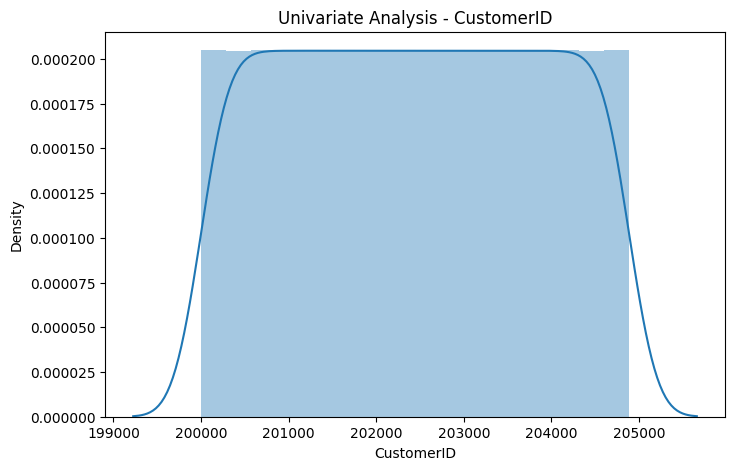

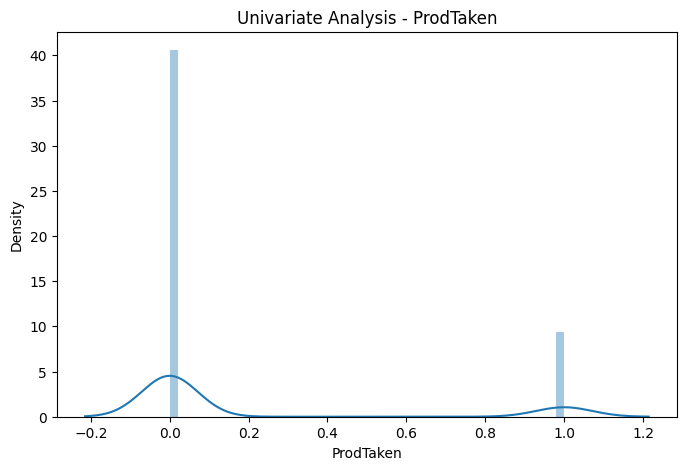

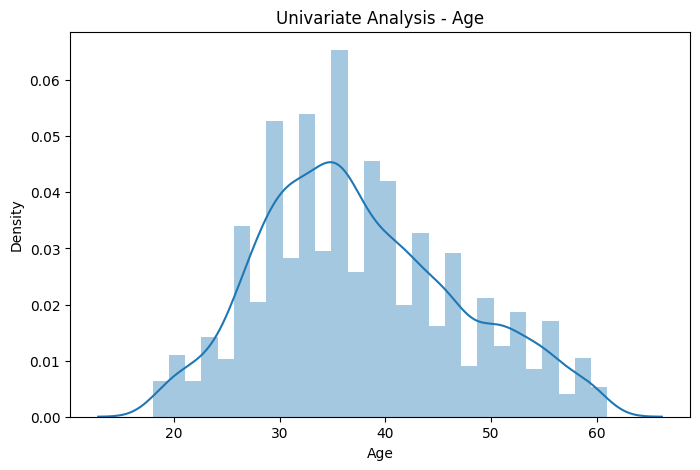

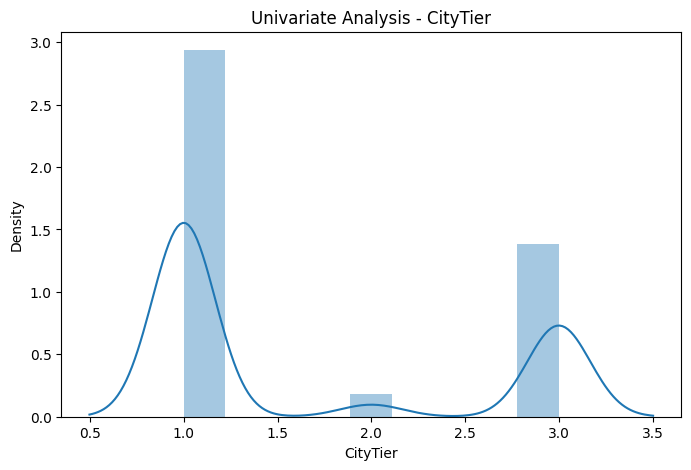

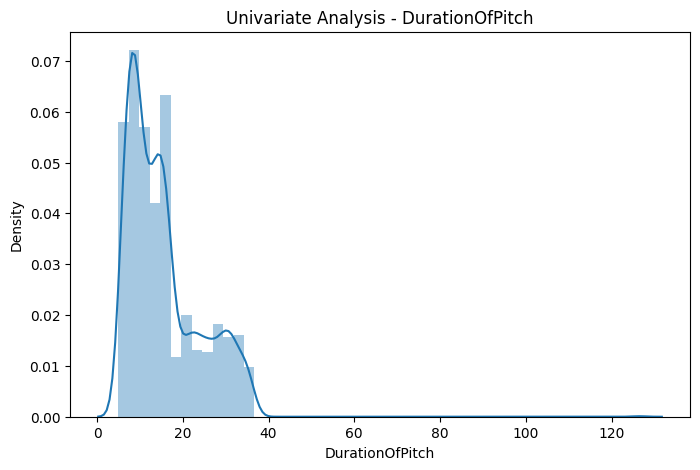

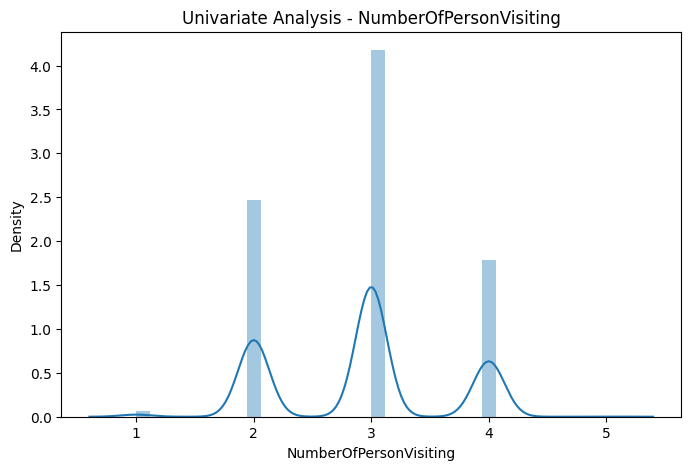

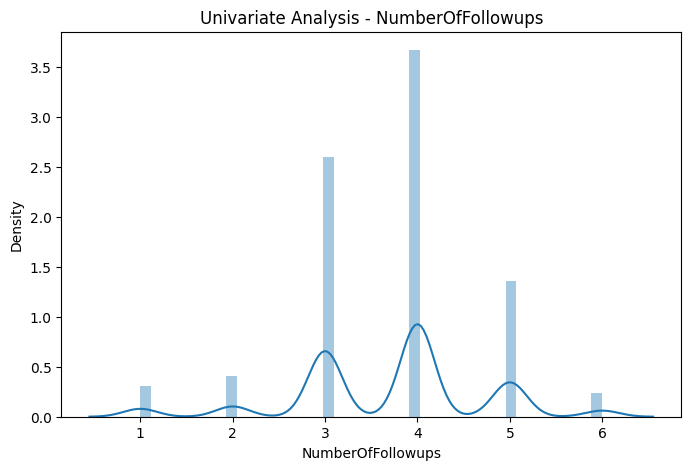

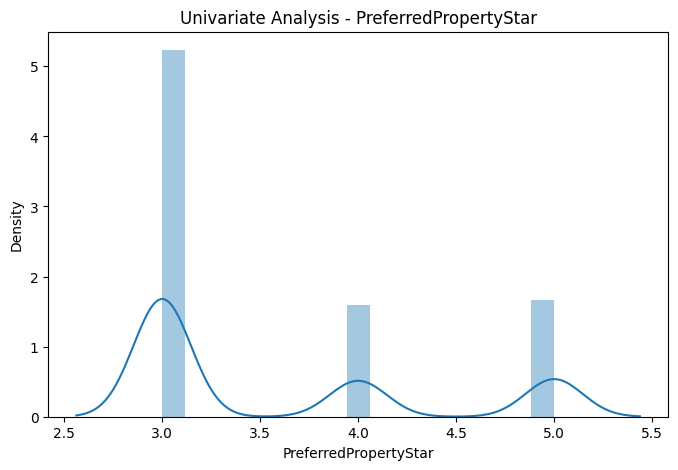

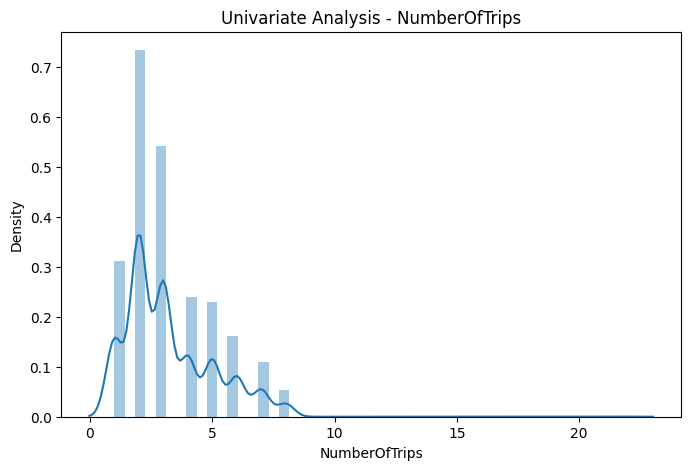

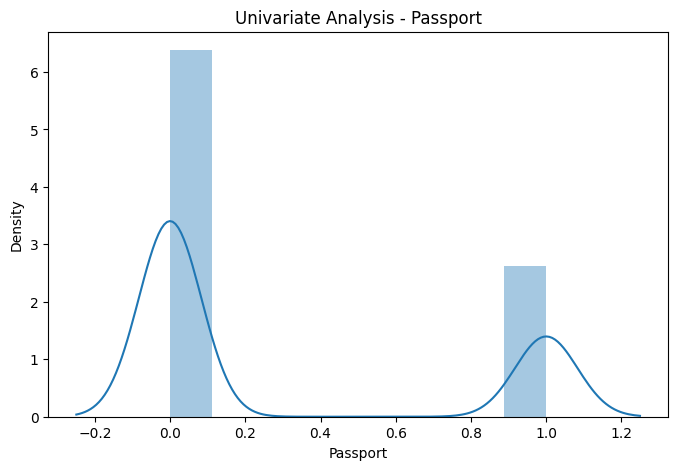

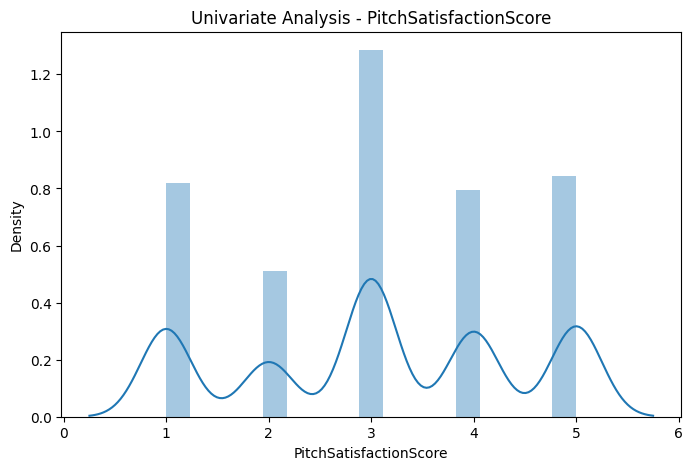

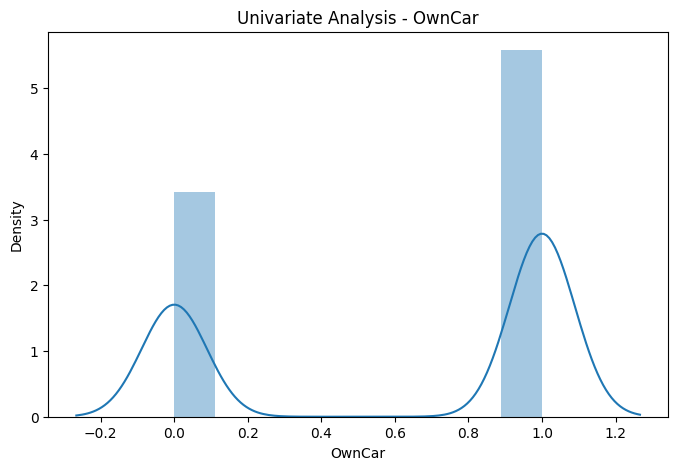

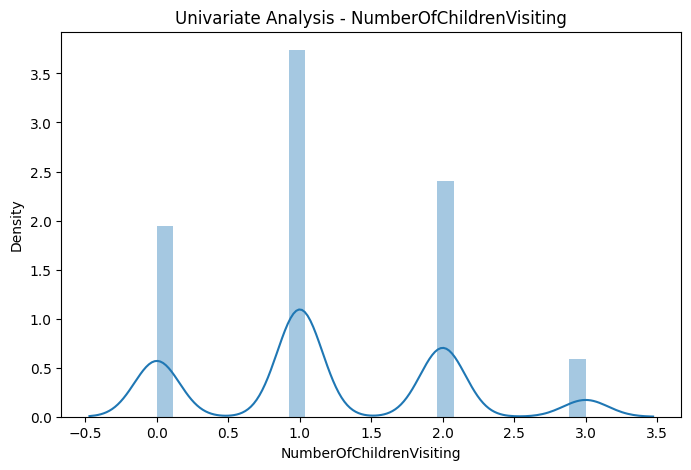

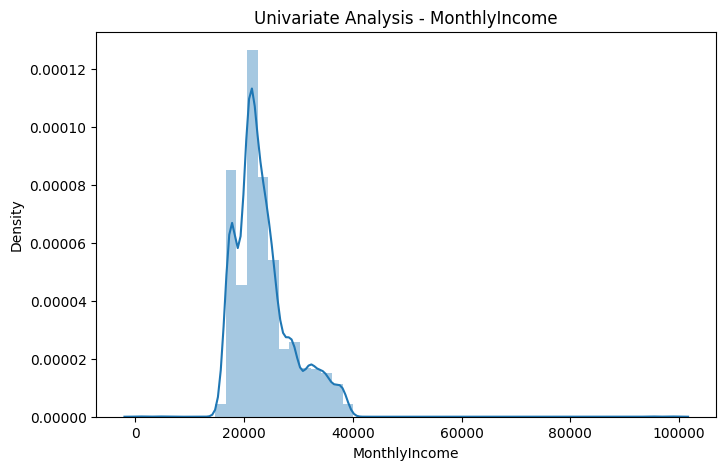

In [19]:
  for column in num_col:
    plt.figure(figsize = (8,5))
    sns.distplot(df[column], kde = True)
    plt.title(f"Univariate Analysis - {column}")
    plt.show()

In [20]:
df[num_col].describe()

,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4888.000000,4888.000000,4662.000000,4888.000000,4637.000000,4888.000000,4843.000000,4862.000000,4748.000000,4888.000000,4888.000000,4888.000000,4822.000000,4655.000000
mean,202443.500000,0.188216,37.622265,1.654255,15.490835,2.905074,3.708445,3.581037,3.236521,0.290917,3.078151,0.620295,1.187267,23619.853491
std,1411.188388,0.390925,9.316387,0.916583,8.519643,0.724891,1.002509,0.798009,1.849019,0.454232,1.365792,0.485363,0.857861,5380.698361
min,200000.000000,0.000000,18.000000,1.000000,5.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1000.000000
25%,201221.750000,0.000000,31.000000,1.000000,9.000000,2.000000,3.000000,3.000000,2.000000,0.000000,2.000000,0.000000,1.000000,20346.000000
50%,202443.500000,0.000000,36.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,3.000000,1.000000,1.000000,22347.000000
75%,203665.250000,0.000000,44.000000,3.000000,20.000000,3.000000,4.000000,4.000000,4.000000,1.000000,4.000000,1.000000,2.000000,25571.000000
max,204887.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,5.000000,1.000000,3.000000,98678.000000


In [21]:
for i in df[cat_col].columns:
  x = df[i].unique()
  print(f"{i}: {x} ")
  print()

TypeofContact: ['Self Enquiry' 'Company Invited' nan] 

Occupation: ['Salaried' 'Free Lancer' 'Small Business' 'Large Business'] 

Gender: ['Female' 'Male'] 

ProductPitched: ['Deluxe' 'Basic' 'Standard' 'Super Deluxe' 'King'] 

MaritalStatus: ['Single' 'Divorced' 'Married' 'Unmarried'] 

Designation: ['Manager' 'Executive' 'Senior Manager' 'AVP' 'VP'] 



<Axes: xlabel='Age', ylabel='DurationOfPitch'>

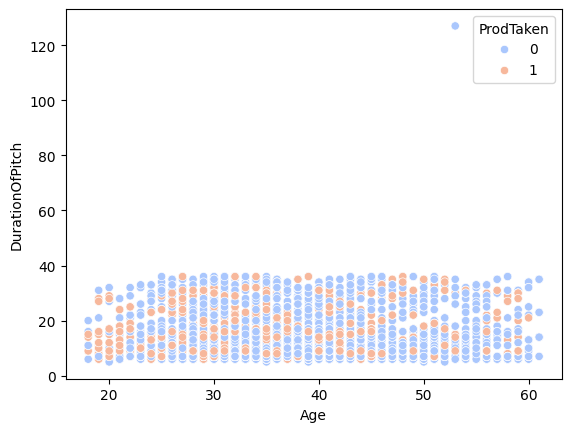

In [22]:
sns.scatterplot(x= 'Age', y = 'DurationOfPitch', data = df, hue = 'ProdTaken', palette = 'coolwarm')

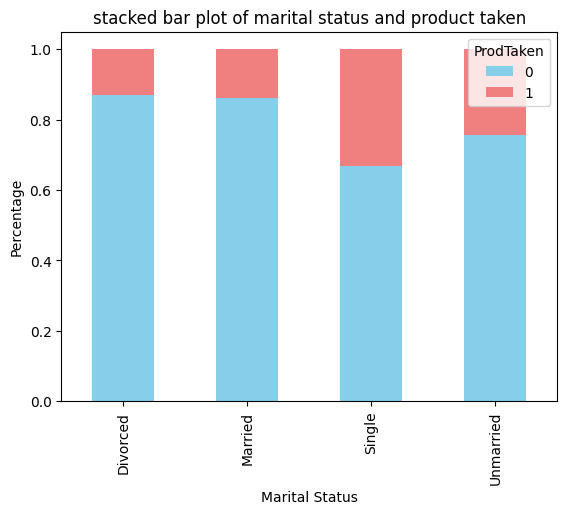

In [23]:
cross_tab = pd.crosstab(df['MaritalStatus'], df['ProdTaken'], normalize = 'index')
cross_tab.plot(kind = 'bar', stacked = True, color = ['skyblue', 'lightcoral'])
plt.title('stacked bar plot of marital status and product taken')
plt.xlabel('Marital Status')
plt.ylabel('Percentage')
plt.show()

In [24]:
df.Gender.value_counts(normalize = True)

,proportion
Gender,
Male,0.596563
Female,0.403437


In [25]:
df.Gender.value_counts()

,count
Gender,
Male,2916
Female,1972


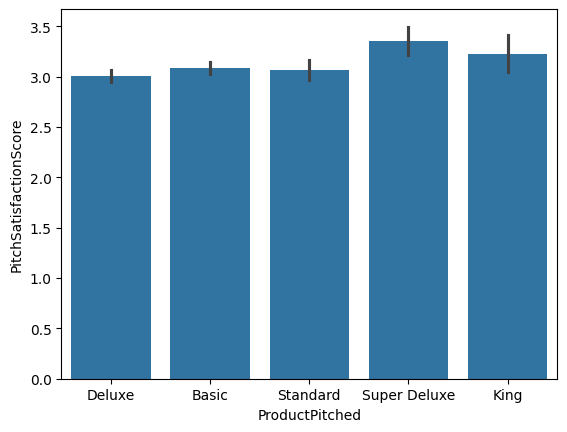

In [26]:
sns.barplot(x = 'ProductPitched', y = 'PitchSatisfactionScore', data = df)
plt.show()

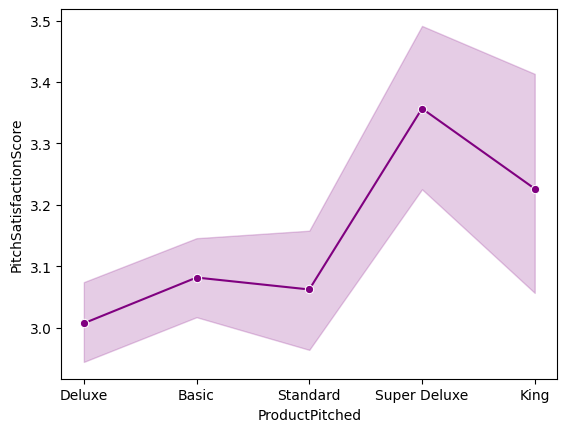

In [31]:
sns.lineplot(x = 'ProductPitched', y = 'PitchSatisfactionScore', data = df,
             marker = 'o', color = 'purple')
plt.show()

In [32]:
cross_table = pd.crosstab(df['MaritalStatus'], df['ProdTaken'])
cross_table

ProdTaken,0,1
MaritalStatus,,
Divorced,826,124
Married,2014,326
Single,612,304
Unmarried,516,166


# Multivariate analysis

<Axes: xlabel='ProdTaken', ylabel='Age'>

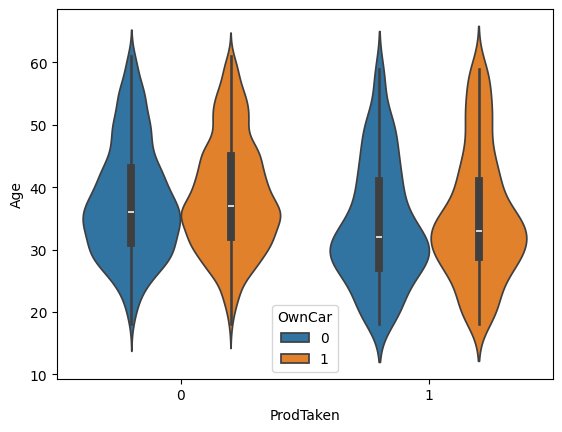

In [33]:
sns.violinplot ( x = "ProdTaken", y = 'Age', data = df, hue = 'OwnCar' )

<Axes: xlabel='Gender', ylabel='Age'>

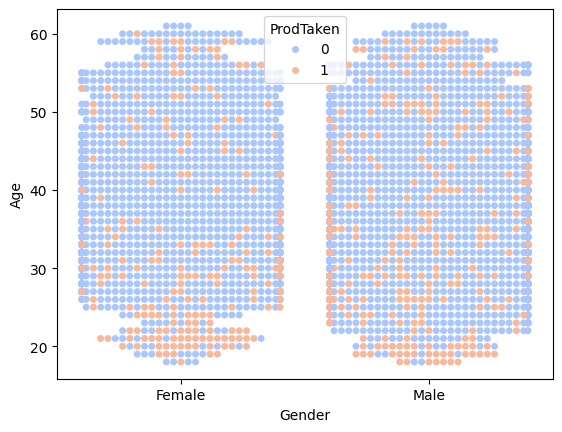

In [38]:
sns.swarmplot(x= 'Gender', y = 'Age', data = df, hue = 'ProdTaken', palette = 'coolwarm')

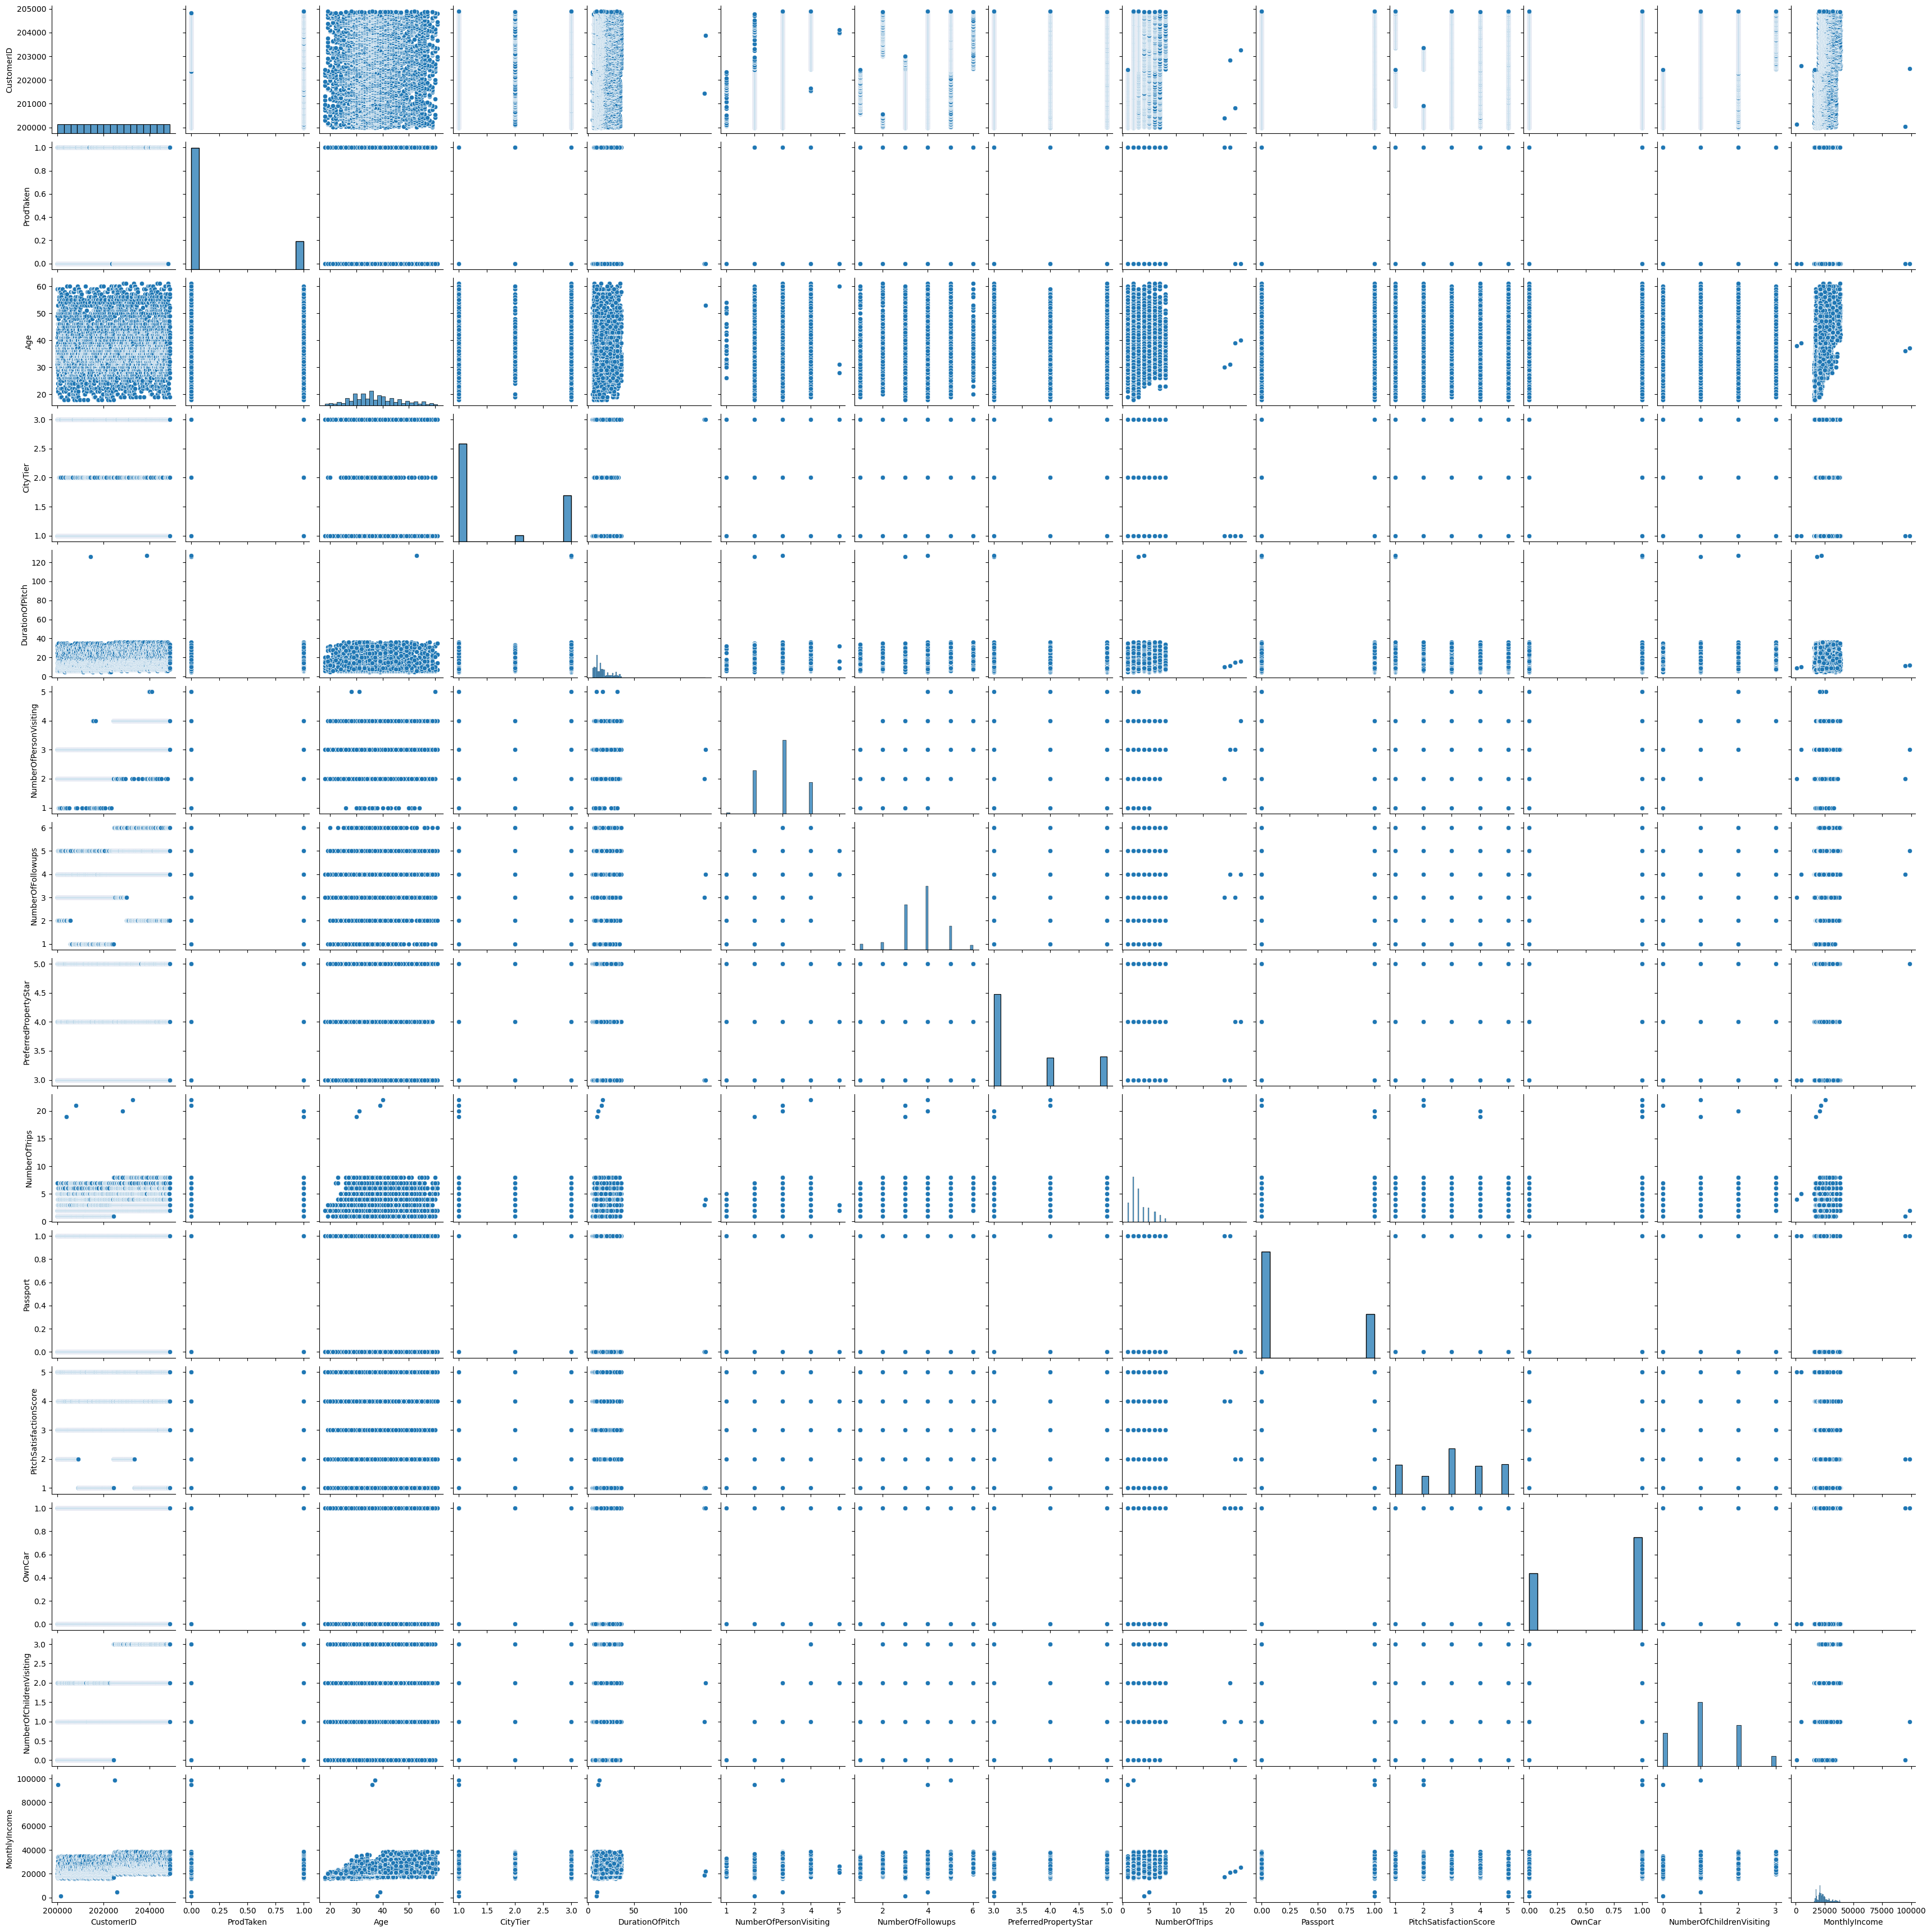

In [39]:
sns.pairplot(df[num_col])

In [41]:
corr_df = df[num_col].corr()
corr_df

,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
CustomerID,1.000000,0.056506,0.032127,0.012975,0.064298,0.604013,0.427539,0.010553,0.224848,0.007974,-0.035847,0.003805,0.511763,0.276833
ProdTaken,0.056506,1.000000,-0.147254,0.086852,0.078257,0.009627,0.112171,0.099577,0.018898,0.260844,0.051394,-0.011508,0.007421,-0.130585
Age,0.032127,-0.147254,1.000000,-0.015625,-0.012063,0.011621,-0.002577,-0.010474,0.184905,0.033399,0.018510,0.048654,0.007370,0.464869
CityTier,0.012975,0.086852,-0.015625,1.000000,0.022703,-0.001671,0.023652,-0.009164,-0.029709,0.001793,-0.042160,0.003817,0.000672,0.051817
DurationOfPitch,0.064298,0.078257,-0.012063,0.022703,1.000000,0.065141,0.009434,-0.006637,0.009715,0.033034,-0.002880,-0.001626,0.031408,-0.006252
NumberOfPersonVisiting,0.604013,0.009627,0.011621,-0.001671,0.065141,1.000000,0.328569,0.033867,0.195223,0.011177,-0.019581,0.010362,0.610621,0.195134
NumberOfFollowups,0.427539,0.112171,-0.002577,0.023652,0.009434,0.328569,1.000000,-0.024176,0.139517,0.004970,0.004054,0.012112,0.286425,0.176503
PreferredPropertyStar,0.010553,0.099577,-0.010474,-0.009164,-0.006637,0.033867,-0.024176,1.000000,0.012115,0.001040,-0.022701,0.015742,0.035798,0.014289
NumberOfTrips,0.224848,0.018898,0.184905,-0.029709,0.009715,0.195223,0.139517,0.012115,1.000000,0.012949,-0.004378,-0.011825,0.168795,0.139105
Passport,0.007974,0.260844,0.033399,0.001793,0.033034,0.011177,0.004970,0.001040,0.012949,1.000000,0.002926,-0.022330,0.020264,0.002545


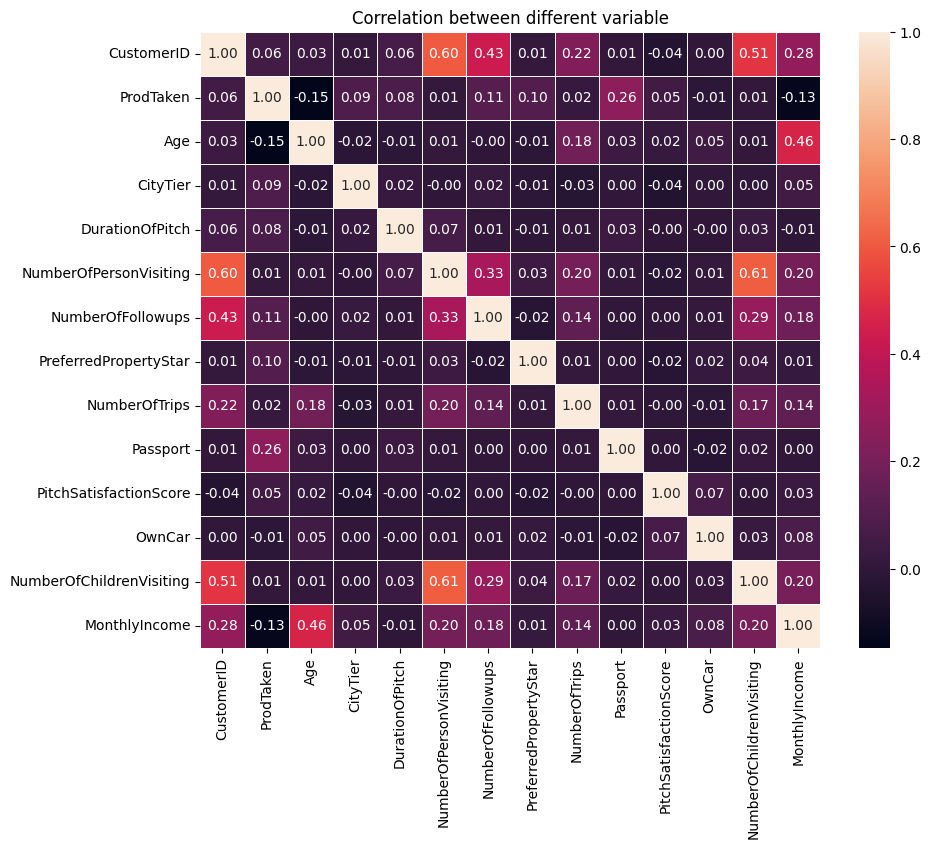

In [49]:
f, ax = plt.subplots(figsize = (10,8))
sns.heatmap(corr_df, annot = True, fmt = ".2f", ax = ax, linewidth = 0.5 )

plt.title('Correlation between different variable')
plt.show()

In [51]:
from mpl_toolkits.mplot3d import Axes3D

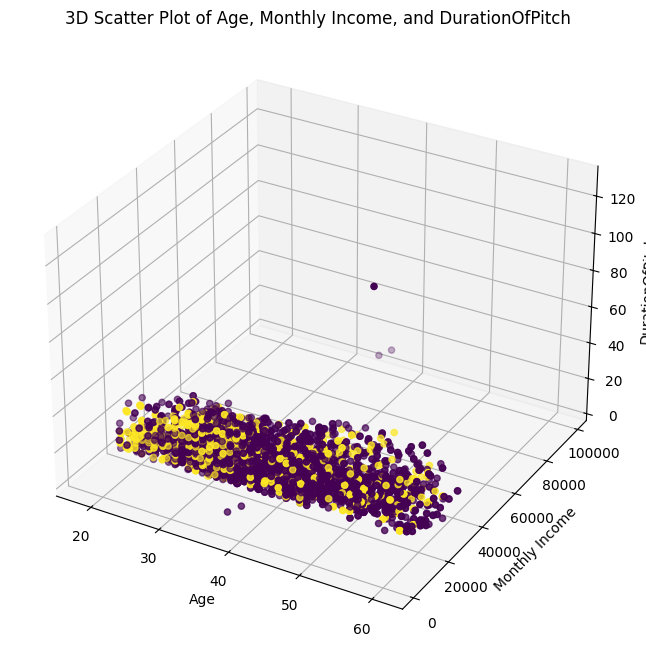

In [57]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(df["Age"], df['MonthlyIncome'], df['DurationOfPitch'], c = df['ProdTaken'], cmap = 'viridis', )
ax.set_xlabel('Age')
ax.set_ylabel('Monthly Income')
ax.set_zlabel('DurationOfPitch')
ax.set_title('3D Scatter Plot of Age, Monthly Income, and DurationOfPitch')
plt.show()